## Feature Engineering

To transform the time series into a supervised learning problem, several features were created:

### Time-Based Features
- Hour of the day
- Day of the week
- Month
- Day of the year

### Lag Features
- `lag_24`: Value from 24 hours ago
- `lag_168`: Value from 168 hours ago (1 week)

### Rolling Statistics
- 24-hour moving average
- 168-hour moving average

These features help the model capture temporal dependencies and repeating patterns in energy demand.

In [5]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, project_root)

print(project_root)

/Users/handanvural/Desktop/MyProjects/energy camp/energy-demand-forecasting-system


# Data Preparation Pipeline

In this project, data preprocessing is centralized using a pipeline function.

## Steps:
1. Load raw data (`load_and_clean`)
2. Generate time-based and lag features (`create_features`)
3. Return final processed dataset

## Why this approach?

- Avoids code duplication
- Ensures consistency across training and inference
- Makes the project modular and scalable
- Follows real-world machine learning pipeline design

## Usage:

```python
from app.utils import prepare_data

df = prepare_data("../data/PJME_hourly.csv")

In [6]:
from app.utils import load_and_clean, create_features

df = load_and_clean("../data/PJME_hourly.csv")
df = create_features(df)
print(df.head())

                     PJME_MW  hour  day_of_week  month  day_of_year   lag_24  \
Datetime                                                                       
2002-12-24 01:00:00  27213.0     1            1     12          358  27669.0   
2002-12-24 02:00:00  25643.0     2            1     12          358  26162.0   
2002-12-24 03:00:00  24907.0     3            1     12          358  25483.0   
2002-12-24 04:00:00  24721.0     4            1     12          358  25045.0   
2002-12-24 05:00:00  25144.0     5            1     12          358  25030.0   

                     lag_168  rolling_mean_24  rolling_mean_168  
Datetime                                                         
2002-12-24 01:00:00  26498.0        29475.375      30894.589286  
2002-12-24 02:00:00  25147.0        29453.750      30897.541667  
2002-12-24 03:00:00  24574.0        29429.750      30899.523810  
2002-12-24 04:00:00  24393.0        29416.250      30901.476190  
2002-12-24 05:00:00  24860.0        29421.0

<Axes: title={'center': 'Actual vs Lag 24'}, xlabel='Datetime'>

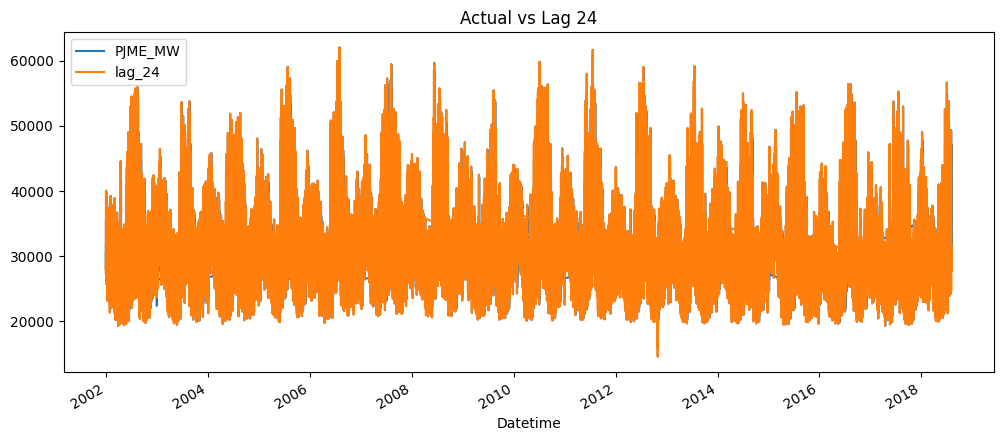

In [ ]:
df[["PJME_MW", "lag_24"]].plot(figsize=(12,5), title="Actual vs Lag 24")

## Train-Test Split

Since this is a time series problem, random splitting is not appropriate.

Instead, a time-based split was used:

- Training data: Before 2015
- Testing data: After 2015

This ensures the model is evaluated on future, unseen data, mimicking real-world conditions.

In [ ]:
split_date = "2015-01-01"

train = df[df.index < split_date]
test = df[df.index >= split_date]

print(train.shape, test.shape)

(113758, 9) (31440, 9)


In [ ]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

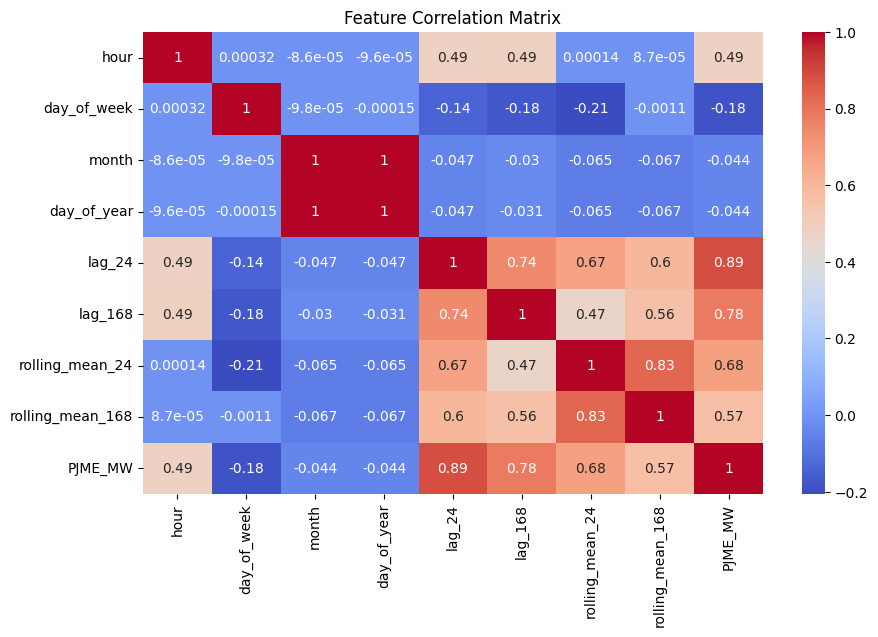

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df[features + [target]].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
df.to_csv("../data/processed_data.csv")